# 卷积神经网络：PyTorch 应用实战

本实验将使用 PyTorch 实现两个图像分类任务：

- 使用 `nn.Sequential` 构建情绪分类器（二分类）
- 使用自定义 `nn.Module` 构建手语数字识别网络（多分类）

**完成本实验后，你将能够：**

- 在 PyTorch 中搭建并训练用于**二分类**的卷积神经网络
- 在 PyTorch 中搭建并训练用于**多分类**的卷积神经网络
- 掌握 PyTorch `nn.Sequential` 与自定义 `nn.Module` 的使用方式
- 手动编写 PyTorch 训练循环（前向传播、损失计算、反向传播、参数更新）

## 目录

- [1 - 导入依赖包](#1)
    - [1.1 - 加载数据集](#1-1)
- [2 - Sequential 模型（HappyModel）](#2)
    - [2.1 - 构建序列模型](#2-1)
    - [2.2 - 训练与评估](#2-2)
- [3 - 自定义 Module（手语识别）](#3)
    - [3.1 - 加载 SIGNS 数据集](#3-1)
    - [3.2 - 数据预处理](#3-2)
    - [3.3 - 前向传播设计](#3-3)
    - [3.4 - 训练模型](#3-4)
- [4 - 训练历史与可视化](#4)

<a name='1'></a>
## 1 - 导入依赖包

在开始之前，先导入本实验所需的所有库。

In [1]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from cnn_utils_torch import load_happy_dataset, load_signs_dataset, convert_to_one_hot

%matplotlib inline
np.random.seed(1)
torch.manual_seed(1)

<a name='1-1'></a>
### 1.1 - 导入数据并划分训练集与测试集

在这一节中，我们将导入 Happy House 数据集，并将其划分为**训练集**和**测试集**两部分。数据集中的图像尺寸为 **64×64** 像素，RGB 三通道，任务是二分类：微笑（1）vs. 不微笑（0）。


In [2]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_happy_dataset()

# Normalize image vectors
X_train_np = X_train_orig / 255.
X_test_np  = X_test_orig  / 255.

# Reshape labels: (1, m) -> (m,)
Y_train_np = Y_train_orig.T.astype(np.float32).reshape(-1)
Y_test_np  = Y_test_orig.T.astype(np.float32).reshape(-1)

print("number of training examples =", X_train_np.shape[0])
print("number of test examples =",     X_test_np.shape[0])
print("X_train shape:", X_train_np.shape)
print("Y_train shape:", Y_train_np.shape)
print("X_test shape:",  X_test_np.shape)
print("Y_test shape:",  Y_test_np.shape)

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600,)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150,)


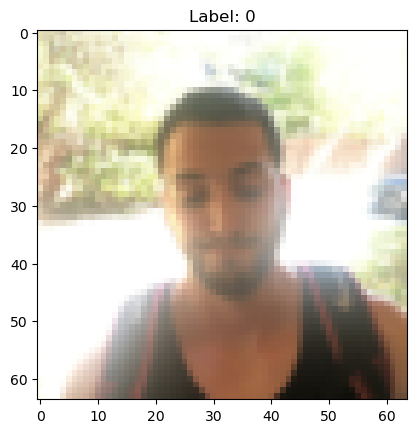

In [3]:
index = 124
plt.imshow(X_train_orig[index])
plt.title(f"Label: {int(Y_train_np[index])}")
plt.show()

<a name='2'></a>
## 2 - Sequential 模型（HappyModel）

<a name='2-1'></a>
### 2.1 - 构建序列模型

在本节中，我们将使用 PyTorch 搭建一个卷积神经网络，对图片中的人是否微笑进行二分类。

模型需要实现以下结构：

$$\text{ZeroPad2d} \rightarrow \text{Conv2d} \rightarrow \text{BatchNorm2d} \rightarrow \text{ReLU} \rightarrow \text{MaxPool2d} \rightarrow \text{Flatten} \rightarrow \text{Linear} \rightarrow \text{Sigmoid}$$

**你的任务：** 在下方代码框的 `### START CODE HERE ###` 与 `### END CODE HERE ###` 之间，使用 `nn.Sequential` 完成模型的搭建。需要用到的 PyTorch 模块如下：

| 模块 | 作用 |
|---|---|
| `nn.ZeroPad2d(padding)` | 在输入特征图的四周填充零 |
| `nn.Conv2d(in_channels, out_channels, kernel_size, stride)` | 二维卷积层 |
| `nn.BatchNorm2d(num_features)` | 批归一化，`num_features` 取当前通道数 |
| `nn.ReLU()` | ReLU 激活函数 |
| `nn.MaxPool2d(kernel_size, stride)` | 最大池化层 |
| `nn.Flatten()` | 将多维特征图展平为一维向量 |
| `nn.Linear(in_features, out_features)` | 全连接层 |
| `nn.Sigmoid()` | Sigmoid 激活函数，将输出映射到 (0, 1) |

> **提示：** 请参考代码框中 docstring 里的形状推导表，逐层计算各参数的正确取值。


In [4]:
def happyModel():
    """
    实现以下结构的卷积神经网络（Sequential 模型）：
    ZeroPad2d -> Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d -> Flatten -> Linear -> Sigmoid

    输入形状:  (N, 3, 64, 64)  [channels-first, 即 (批大小, 通道数, 高, 宽)]
    输出形状: (N, 1)

    各层参数推导提示：
    ┌─────────────────────────────────────────────────────────────────────┐
    │ 层                  │ 参数推导思路                                   │
    ├─────────────────────────────────────────────────────────────────────┤
    │ ZeroPad2d(p)        │ 目标：使 7×7 卷积后空间尺寸仍为 64×64。        │
    │                     │ Conv 输出尺寸 = (H + 2p - k) / s + 1          │
    │                     │ 令输出 = 64, k=7, s=1 → 求 p                  │
    │                     │ → 输入在填充后应变为多少？p = ?                │
    ├─────────────────────────────────────────────────────────────────────┤
    │ Conv2d(C_in, 32,    │ C_in = 上一层的输出通道数（原始图像有几个通道？）│
    │   kernel_size=7,    │ 32 为设计选择（输出通道数），kernel/stride 已给定│
    │   stride=1)         │ 填充后尺寸 → 卷积后尺寸 = ?                    │
    ├─────────────────────────────────────────────────────────────────────┤
    │ BatchNorm2d(C)      │ C = 上一层 Conv2d 的输出通道数 = ?             │
    ├─────────────────────────────────────────────────────────────────────┤
    │ ReLU()              │ 不改变形状                                     │
    ├─────────────────────────────────────────────────────────────────────┤
    │ MaxPool2d(k=2, s=2) │ 输出尺寸 = (H - k) / s + 1                    │
    │                     │ 当前 H=64, k=2, s=2 → 输出空间尺寸 = ?        │
    ├─────────────────────────────────────────────────────────────────────┤
    │ Flatten()           │ 展平后维度 = C × H × W                        │
    │                     │ 此时 C=32, H=?, W=? → in_features = ?         │
    ├─────────────────────────────────────────────────────────────────────┤
    │ Linear(in, 1)       │ in = Flatten 后的维度（见上）                   │
    │                     │ out = 1（二分类，输出一个概率值）               │
    ├─────────────────────────────────────────────────────────────────────┤
    │ Sigmoid()           │ 将线性输出映射到 (0, 1)，不改变形状            │
    └─────────────────────────────────────────────────────────────────────┘
    """
    ### START CODE HERE ###
    ### END CODE HERE ###
    return model

happy_model = happyModel()
print(happy_model)


Sequential(
  (0): ZeroPad2d((3, 3, 3, 3))
  (1): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=32768, out_features=1, bias=True)
  (7): Sigmoid()
)


In [5]:
from test_utils import test_happy_model

test_happy_model(happyModel)


All tests passed


<a name='2-2'></a>
### 2.2 - 训练与评估

在上一步中，我们已经用 `nn.Sequential` 搭建好了 HappyModel 的结构。接下来要对它进行训练。

PyTorch 需要我们手动编写训练循环。每一轮（epoch）的流程如下：

```
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:   # 1. 遍历 mini-batch
        optimizer.zero_grad()               # 2. 清空上一步的梯度
        outputs = model(X_batch)            # 3. 前向传播
        loss = criterion(outputs, y_batch)  # 4. 计算损失
        loss.backward()                     # 5. 反向传播（自动求梯度）
        optimizer.step()                    # 6. 更新参数
```

#### 1. 损失函数（Loss Function）

本节任务是**二分类**（微笑 vs. 不微笑），模型最后一层是 `Sigmoid`，输出值在 $(0, 1)$ 之间，表示属于正类的概率。因此选用：

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

对应 PyTorch 的 `nn.BCELoss()`（Binary Cross-Entropy Loss），与 Keras 的 `binary_crossentropy` 等价。

> **注意：** `BCELoss` 要求输入已经过 Sigmoid 激活，取值在 $(0,1)$；若模型输出的是原始 logit，应改用 `nn.BCEWithLogitsLoss()`（数值更稳定）。

#### 2. 精确度（Accuracy）

PyTorch 本身没有内置的 `accuracy` 指标，需要手动计算。做法是：将模型输出的概率值**按阈值 0.5 取整**，与真实标签比较后求均值：

```python
preds   = (outputs >= 0.5).float()          # 概率 >= 0.5 判为正类（1），否则为负类（0）
correct = (preds == y_batch).sum().item()   # 统计预测正确的样本数
accuracy = correct / total                  # 除以总样本数得到准确率
```

这与 Keras 的 `metrics=['accuracy']` 在二分类场景下的计算逻辑完全一致。


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----- Build PyTorch tensors (N, C, H, W) -----
# X_train_np is (N, H, W, C) -> transpose to (N, C, H, W)
X_train_t = torch.tensor(X_train_np.transpose(0, 3, 1, 2), dtype=torch.float32)
X_test_t  = torch.tensor(X_test_np.transpose(0, 3, 1, 2),  dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_np, dtype=torch.float32).unsqueeze(1)  # (N,1)
Y_test_t  = torch.tensor(Y_test_np,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  Y_test_t),  batch_size=16, shuffle=False)

# ----- Training -----
happy_model = happyModel().to(device)
optimizer   = optim.Adam(happy_model.parameters())
criterion   = nn.BCELoss()

def train_model(model, loader, optimizer, criterion, epochs=10):
    history = {"loss": [], "accuracy": []}
    model.train()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total   += X_batch.size(0)
        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs}  loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}")
    return history

history_happy = train_model(happy_model, train_loader, optimizer, criterion, epochs=10)

Using device: cpu
Epoch 1/10  loss: 1.2589  acc: 0.6917
Epoch 2/10  loss: 0.2734  acc: 0.8800
Epoch 3/10  loss: 0.1813  acc: 0.9300
Epoch 4/10  loss: 0.1205  acc: 0.9483
Epoch 5/10  loss: 0.1197  acc: 0.9567
Epoch 6/10  loss: 0.1100  acc: 0.9617
Epoch 7/10  loss: 0.1125  acc: 0.9517
Epoch 8/10  loss: 0.1417  acc: 0.9450
Epoch 9/10  loss: 0.1162  acc: 0.9667
Epoch 10/10  loss: 0.0651  acc: 0.9733


In [7]:
def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total   += X_batch.size(0)
    print(f"Test  loss: {running_loss/total:.4f}  accuracy: {correct/total:.4f}")

evaluate_model(happy_model, test_loader, criterion)

Test  loss: 0.1214  accuracy: 0.9600


<a name='3'></a>
## 3 - 自定义 Module（手语识别）

<a name='3-1'></a>
### 3.1 - 加载 SIGNS 数据集

SIGNS 数据集包含手语数字图像，共 6 个类别（0 到 5）。


In [8]:
# Loading the data (signs)
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_signs_dataset()

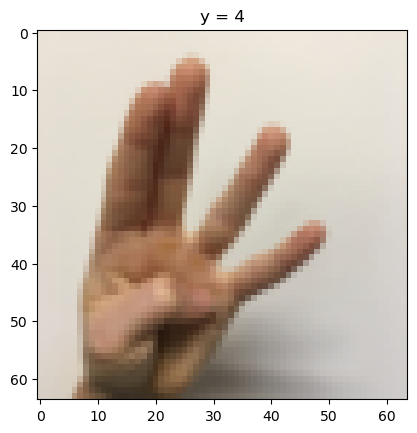

In [9]:
index = 9
plt.imshow(X_train_orig[index])
plt.title("y = " + str(np.squeeze(Y_train_orig[:, index])))
plt.show()

<a name='3-2'></a>
### 3.2 - 数据预处理与数据集划分

在这一步中，我们对数据做两件事：

1. **归一化像素值**：将图像像素值从 $[0, 255]$ 缩放到 $[0, 1]$，即除以 255，有助于加快模型收敛。

2. **转换标签格式**：原始标签 `Y` 的形状为 `(1, m)`，我们将其 `reshape` 为一维数组 `(m,)`，并转换为 `np.int64` 类型（整数类索引）。

   > PyTorch 的 `CrossEntropyLoss` 要求标签是**整数类索引**（如 0、1、2、3、4、5），而不是 one-hot 向量。它内部已经完成了 softmax + log + NLLLoss 的计算，因此模型输出原始 logit 即可，无需手动添加 softmax 层。


In [10]:
X_train_np = X_train_orig / 255.
X_test_np  = X_test_orig  / 255.

# Y_train_orig shape: (1, m) -> class indices (m,)
Y_train_np = Y_train_orig.reshape(-1).astype(np.int64)
Y_test_np  = Y_test_orig.reshape(-1).astype(np.int64)

print("number of training examples =", X_train_np.shape[0])
print("number of test examples =",     X_test_np.shape[0])
print("X_train shape:", X_train_np.shape)
print("Y_train shape:", Y_train_np.shape)
print("X_test shape:",  X_test_np.shape)
print("Y_test shape:",  Y_test_np.shape)

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080,)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120,)


<a name='3-3'></a>
### 3.3 - 前向传播设计

在 PyTorch 中，自定义网络结构通过继承 `nn.Module` 并在 `forward()` 方法中显式描述数据流来实现，这与直接定义计算图的方式等价，灵活性更高。

**网络结构：** `CONV2D → RELU → MAXPOOL → CONV2D → RELU → MAXPOOL → FLATTEN → LINEAR`

各层参数如下：

| 层 | 参数 |
|---|---|
| Conv2d | 8 个滤波器，4×4，stride=1，padding='same' |
| ReLU | 无参数 |
| MaxPool2d | 窗口 8×8，stride=8 |
| Conv2d | 16 个滤波器，2×2，stride=1，padding='same' |
| ReLU | 无参数 |
| MaxPool2d | 窗口 4×4，stride=4 |
| Flatten | 无参数 |
| Linear | 64 → 6（原始 logit，损失函数内置 softmax）|

> **注意：** PyTorch 的 `Conv2d` 设置 `padding='same'` 时，输出空间尺寸与输入保持一致。`CrossEntropyLoss` 内部已包含 `log_softmax` 运算，因此模型最后一层无需添加 softmax 激活。

**你的任务：** 在下方代码框的 `### START CODE HERE ###` 与 `### END CODE HERE ###` 之间，完成 `ConvolutionalModel` 中各层的定义。请按照上表的参数，在 `__init__` 中依次设置以下属性：

| 属性名 | 模块 | 关键参数推导提示 |
|---|---|---|
| `self.conv1` | `nn.Conv2d` | 输入通道 = 原始 RGB 图像通道数；输出通道 = 8；kernel=4, stride=1, padding='same' |
| `self.relu1` | `nn.ReLU()` | 无参数 |
| `self.pool1` | `nn.MaxPool2d` | kernel=8, stride=8（空间尺寸 64 → 8）|
| `self.conv2` | `nn.Conv2d` | 输入通道 = pool1 的输出通道数；输出通道 = 16；kernel=2, stride=1, padding='same' |
| `self.relu2` | `nn.ReLU()` | 无参数 |
| `self.pool2` | `nn.MaxPool2d` | kernel=4, stride=4（空间尺寸 8 → 2）|
| `self.flatten` | `nn.Flatten()` | 无参数 |
| `self.fc` | `nn.Linear` | in_features = 16 × H × W（H、W 为 pool2 后的空间尺寸）；out_features = 类别数 |

> **形状推导（以输入 (N, 3, 64, 64) 为例）：**
> 1. Conv1（padding='same'）→ **(N, 8, 64, 64)**
> 2. Pool1（kernel=8, stride=8）→ **(N, 8, 8, 8)**
> 3. Conv2（padding='same'）→ **(N, 16, 8, 8)**
> 4. Pool2（kernel=4, stride=4）→ **(N, 16, 2, 2)**
> 5. Flatten → **(N, 16×2×2) = (N, 64)**
> 6. Linear(64, 6) → **(N, 6)**

In [11]:
class ConvolutionalModel(nn.Module):
    """
    Implements:
    CONV2D(8, 4x4, same) -> RELU -> MAXPOOL(8x8, stride 8)
    -> CONV2D(16, 2x2, same) -> RELU -> MAXPOOL(4x4, stride 4)
    -> FLATTEN -> LINEAR(64, 6)

    Input shape:  (N, 3, 64, 64)
    Output shape: (N, 6)  -- raw logits, use CrossEntropyLoss
    """
    def __init__(self):
        super().__init__()
        ### START CODE HERE ###
        # Block 1: Conv(8 filters, 4x4, same) -> ReLU -> MaxPool(8x8, stride 8)
        # 输入通道数 = ?（原始 RGB 图像有几个颜色通道？）
        # Conv padding='same' 保持空间尺寸不变：64 -> 64
        # MaxPool(kernel=8, stride=8) 使空间尺寸：64 -> 8

        # Block 2: Conv(16 filters, 2x2, same) -> ReLU -> MaxPool(4x4, stride 4)
        # 输入通道数 = Block 1 的输出通道数 = ?
        # Conv padding='same' 保持空间尺寸不变：8 -> 8
        # MaxPool(kernel=4, stride=4) 使空间尺寸：8 -> 2

        # Classifier: Flatten -> Linear
        # Flatten 后维度 = 通道数 × H × W = 16 × ? × ? = ?
        # 输出维度 = 类别数 = ?（0~5 共几类？）
        ### END CODE HERE ###

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x


def convolutional_model(input_shape=(64, 64, 3)):
    """Wrapper that returns a ConvolutionalModel instance."""
    return ConvolutionalModel()


conv_model = convolutional_model((64, 64, 3)).to(device)
print(conv_model)

# Quick shape check
with torch.no_grad():
    dummy = torch.zeros(1, 3, 64, 64).to(device)
    out   = conv_model(dummy)
    print("Output shape:", out.shape)  # should be (1, 6)

ConvolutionalModel(
  (conv1): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
Output shape: torch.Size([1, 6])


/opt/anaconda3/envs/pt/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226120/work/aten/src/ATen/native/Convolution.cpp:1041.)
  return F.conv2d(input, weight, bias, self.stride,


In [12]:
from test_utils import test_convolutional_model

test_convolutional_model(convolutional_model)


All tests passed


<a name='3-4'></a>
### 3.4 - 训练模型

在这一步中，我们将训练上面搭建好的 `ConvolutionalModel`，使其能够识别手势数字（0~5）。

训练流程与 2.2 节完全一致，区别在于这里是**多分类**任务，因此：

#### 1. 损失函数（Loss Function）

本节任务有 **6 个类别**（手势数字 0~5），模型输出的是**原始 logit**（未经 softmax），因此选用：

$$\mathcal{L} = -\sum_{c=0}^{5} y_c \log \hat{p}_c$$

对应 PyTorch 的 `nn.CrossEntropyLoss()`，与 Keras 的 `categorical_crossentropy` 等价。

> **注意：** `CrossEntropyLoss` 内部已包含 softmax 计算，因此模型最后一层**不需要**手动添加 softmax；标签格式应为**整数类索引**（如 0、1、2、3、4、5），而非 one-hot 向量。

#### 2. 精确度（Accuracy）

与二分类类似，多分类的准确率通过逐样本比较预测类别与真实标签来计算：

```python
preds   = logits.argmax(dim=1)              # 取 logit 最大值对应的类别索引
correct = (preds == y_batch).sum().item()   # 统计预测正确的样本数
accuracy = correct / total                  # 除以总样本数得到准确率
```



In [13]:
# ----- Build tensors (N, C, H, W) -----
X_train_t = torch.tensor(X_train_np.transpose(0, 3, 1, 2), dtype=torch.float32)
X_test_t  = torch.tensor(X_test_np.transpose(0, 3, 1, 2),  dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_np, dtype=torch.long)
Y_test_t  = torch.tensor(Y_test_np,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  Y_test_t),  batch_size=64, shuffle=False)

# ----- Training -----
conv_model  = convolutional_model((64, 64, 3)).to(device)
optimizer   = optim.Adam(conv_model.parameters())
criterion   = nn.CrossEntropyLoss()

def train_multiclass(model, train_loader, val_loader, optimizer, criterion, epochs=100):
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    for epoch in range(epochs):
        # --- train ---
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * X_b.size(0)
            correct  += (logits.argmax(1) == y_b).sum().item()
            total    += X_b.size(0)
        # --- validate ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                val_loss    += criterion(logits, y_b).item() * X_b.size(0)
                val_correct += (logits.argmax(1) == y_b).sum().item()
                val_total   += X_b.size(0)
        history["loss"].append(run_loss / total)
        history["accuracy"].append(correct / total)
        history["val_loss"].append(val_loss / val_total)
        history["val_accuracy"].append(val_correct / val_total)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}  "
                  f"loss: {history['loss'][-1]:.4f}  acc: {history['accuracy'][-1]:.4f}  "
                  f"val_loss: {history['val_loss'][-1]:.4f}  val_acc: {history['val_accuracy'][-1]:.4f}")
    return history

history_signs = train_multiclass(conv_model, train_loader, test_loader, optimizer, criterion, epochs=100)

Epoch  10/100  loss: 1.7031  acc: 0.4407  val_loss: 1.7114  val_acc: 0.4417
Epoch  20/100  loss: 1.2322  acc: 0.5694  val_loss: 1.2852  val_acc: 0.4667
Epoch  30/100  loss: 0.9634  acc: 0.6731  val_loss: 1.0365  val_acc: 0.5750
Epoch  40/100  loss: 0.7885  acc: 0.7380  val_loss: 0.8622  val_acc: 0.6833
Epoch  50/100  loss: 0.6941  acc: 0.7824  val_loss: 0.7839  val_acc: 0.6750
Epoch  60/100  loss: 0.5957  acc: 0.8083  val_loss: 0.7190  val_acc: 0.7167
Epoch  70/100  loss: 0.5417  acc: 0.8287  val_loss: 0.6653  val_acc: 0.7250
Epoch  80/100  loss: 0.4997  acc: 0.8417  val_loss: 0.6240  val_acc: 0.7500
Epoch  90/100  loss: 0.4627  acc: 0.8500  val_loss: 0.5966  val_acc: 0.7583
Epoch 100/100  loss: 0.4274  acc: 0.8593  val_loss: 0.5832  val_acc: 0.7750


<a name='4'></a>
## 4 - 训练历史与可视化

绘制各 epoch 的训练集与验证集损失和准确率曲线，观察模型的收敛情况。

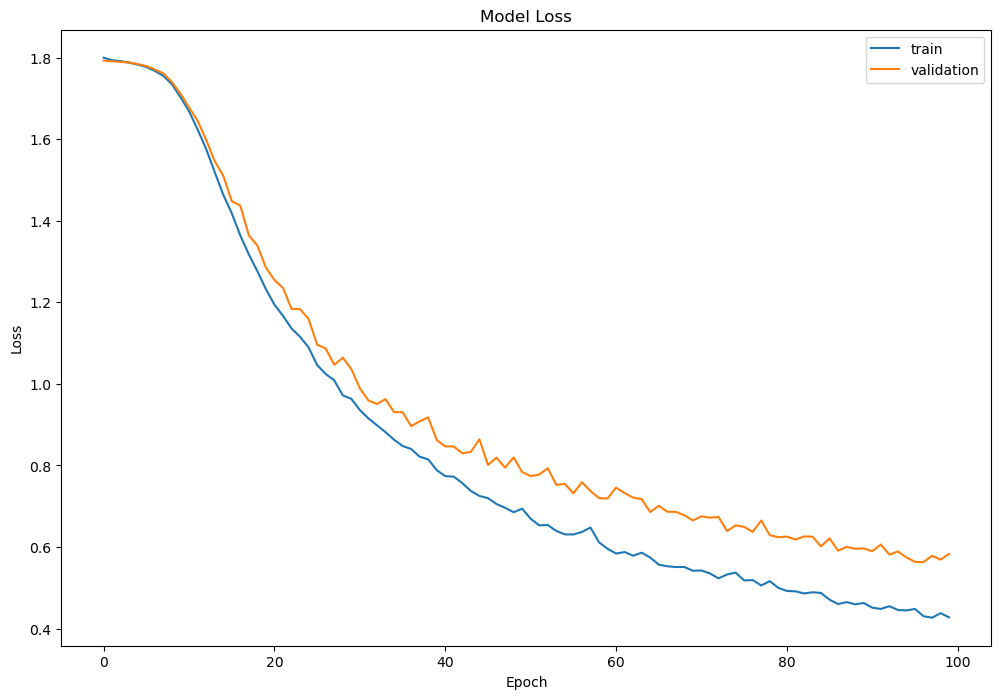

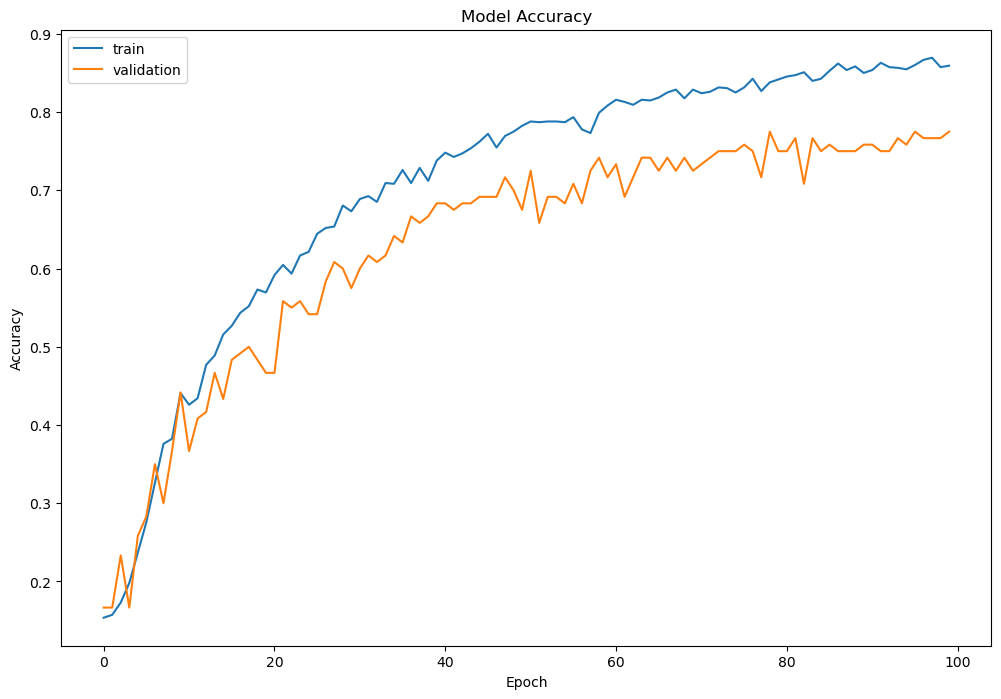

In [14]:
df_history = pd.DataFrame(history_signs)

df_loss = df_history[['loss', 'val_loss']].rename(columns={'loss': 'train', 'val_loss': 'validation'})
df_acc  = df_history[['accuracy', 'val_accuracy']].rename(columns={'accuracy': 'train', 'val_accuracy': 'validation'})

df_loss.plot(title='Model Loss', figsize=(12, 8)).set(xlabel='Epoch', ylabel='Loss')
df_acc.plot(title='Model Accuracy', figsize=(12, 8)).set(xlabel='Epoch', ylabel='Accuracy')
plt.show()